# 04 — Delta Hedging

In this notebook we simulate **discrete-time delta hedging** of a European call
option and study the resulting **hedging error** (also called the profit and loss,
or P&L, of the hedging portfolio).

## The Hedging Strategy

Under continuous rebalancing, a delta hedge is theoretically perfect — the
hedging portfolio exactly replicates the option payoff. In practice, portfolios
can only be rebalanced at **discrete intervals**, which introduces error.

At each rebalancing time $t_i$, the hedger:

1. Computes the current Black–Scholes delta:
$$
\Delta_i = N(d_1(S_{t_i}, K, T - t_i, r, \sigma))
$$
2. Adjusts the stock holding to $\Delta_i$ shares
3. Finances any adjustment by borrowing or lending at the risk-free rate $r$

## Hedging P&L

At expiry $T$, the hedging error is defined as:

$$
\varepsilon_T = V_T^{\text{hedge}} - \max(S_T - K,\, 0)
$$

where $V_T^{\text{hedge}}$ is the terminal value of the replicating portfolio.
Under continuous rebalancing and the GBM model assumptions, $\varepsilon_T = 0$
exactly. Under discrete rebalancing, $\varepsilon_T \neq 0$ in general, and its
distribution characterises the **residual risk** of the hedging strategy.

## What We Will Study

- How hedging error depends on **rebalancing frequency**
- The effect of **volatility misspecification** — hedging with the wrong $\sigma$
- The distribution of terminal hedging P&L across many simulated paths
- How **gamma** drives hedging error: high-gamma regions require more frequent
  rebalancing to maintain an effective hedge

In [2]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import norm
import json
import warnings
warnings.filterwarnings("ignore")

# Consistent plot style across all notebooks
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

In [4]:
# Load Parameters from Notebooks 02 and 03 (GBM_Parameter_Estimation.ipynb and GBM_Option_Pricing.ipynb)
# Load estimated GBM parameters from Notebook 02
with open("estimated_params.json", "r") as f:
    params = json.load(f)

# Load option pricing results from Notebook 03
with open("pricing_output.json", "r") as f:
    pricing = json.load(f)

# GBM and market parameters
S0      = params["s0"]         # initial asset price
sigma   = params["sigma"]      # true volatility (used to simulate paths)
mu      = params["mu"]         # real-world drift (used to simulate paths)
ticker  = params["ticker"]

# Option parameters
K       = pricing["K"]         # strike price
T       = pricing["T"]         # time to expiry in years
r_f     = pricing["r_f"]       # risk-free rate
C0      = pricing["bs_call"]   # initial call price (option premium received)

DT_YEAR = 1 / 252              # one trading day in years

print(f"Loaded parameters for {ticker}")
print(f"  S0     = {S0:.2f}")
print(f"  K      = {K:.2f}")
print(f"  T      = {T} year")
print(f"  r_f    = {r_f}")
print(f"  σ      = {sigma:.4f}")
print(f"  C0     = {C0:.4f}  (initial call premium)")

Loaded parameters for SPY
  S0     = 581.39
  K      = 581.00
  T      = 1.0 year
  r_f    = 0.05
  σ      = 0.1768
  C0     = 55.9364  (initial call premium)


In [5]:
# Black-Scholes Helper Functions
def bs_call_price(S, K, tau, r, sigma):
    """
    Black-Scholes call price.
    tau : time remaining to expiry (years)
    """
    if tau <= 0:
        return max(S - K, 0.0)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))
    d2 = d1 - sigma * np.sqrt(tau)
    return S * norm.cdf(d1) - K * np.exp(-r * tau) * norm.cdf(d2)

def bs_delta(S, K, tau, r, sigma):
    """
    Black-Scholes delta for a European call.
    tau : time remaining to expiry (years)
    """
    if tau <= 0:
        return 1.0 if S > K else 0.0
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))
    return norm.cdf(d1)

def bs_gamma(S, K, tau, r, sigma):
    """
    Black-Scholes gamma for a European call (same for put).
    tau : time remaining to expiry (years)
    """
    if tau <= 0:
        return 0.0
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))
    return norm.pdf(d1) / (S * sigma * np.sqrt(tau))

In [7]:
# Simulate One Hedged Path
def simulate_hedge_path(S0, K, T, r, sigma_true, sigma_hedge,
                        n_steps, seed=None):
    """
    Simulate one GBM path and run a discrete delta hedge along it.

    Parameters
    ----------
    S0           : float  Initial asset price
    K            : float  Strike price
    T            : float  Time to expiry (years)
    r            : float  Risk-free rate
    sigma_true   : float  Volatility used to SIMULATE the asset path
    sigma_hedge  : float  Volatility used to COMPUTE the hedge delta
                          (set equal to sigma_true for a correctly specified hedge;
                           set differently to study misspecification)
    n_steps      : int    Number of rebalancing intervals

    Returns
    -------
    times        : np.ndarray  Shape (n_steps+1,)
    S_path       : np.ndarray  Asset prices along the path
    deltas       : np.ndarray  Delta held at each step
    pnl          : float       Terminal hedging P&L (error)
    """
    rng  = np.random.default_rng(seed)
    dt   = T / n_steps
    times = np.linspace(0, T, n_steps + 1)

    # Simulate asset path under real-world measure 
    Z       = rng.standard_normal(n_steps)
    log_inc = (mu - 0.5 * sigma_true**2) * dt + sigma_true * np.sqrt(dt) * Z
    S_path  = np.empty(n_steps + 1)
    S_path[0] = S0
    for i in range(n_steps):
        S_path[i + 1] = S_path[i] * np.exp(log_inc[i])

    # Initialise the hedging portfolio
    # The option writer receives the premium C0 and holds -1 call (short position)
    tau0    = T
    delta0  = bs_delta(S0, K, tau0, r, sigma_hedge)

    shares  = delta0                          # shares of stock held
    bond    = C0 - delta0 * S0               # cash position (bond account)
    # bond > 0 means lending; bond < 0 means borrowing

    deltas    = np.empty(n_steps + 1)
    deltas[0] = delta0

    # Rebalancing loop
    for i in range(1, n_steps + 1):
        tau = T - times[i]                   # time remaining to expiry

        # Grow bond account at risk-free rate over one interval
        bond *= np.exp(r * dt)

        # Compute new delta at current stock price and time
        new_delta = bs_delta(S_path[i], K, tau, r, sigma_hedge)
        deltas[i] = new_delta

        # Rebalance: buy/sell shares and finance through bond account
        bond    -= (new_delta - shares) * S_path[i]
        shares   = new_delta

    # Terminal P&L 
    # Portfolio value at expiry: stock position + bond
    portfolio_value = shares * S_path[-1] + bond

    # Option payoff owed to buyer
    option_payoff   = max(S_path[-1] - K, 0)

    # Hedging error: how much the hedge portfolio over/under-delivers
    pnl = portfolio_value - option_payoff

    return times, S_path, deltas, pnl

# Test with a single path
times, S_path, deltas, pnl = simulate_hedge_path(
    S0, K, T, r_f, sigma, sigma, n_steps=252, seed=0
)
print(f"Single path terminal P&L : {pnl:.4f}")
print(f"Initial delta            : {deltas[0]:.4f}")
print(f"Final delta              : {deltas[-1]:.4f}  (should be 0 or 1 at expiry)")

Single path terminal P&L : 0.5288
Initial delta            : 0.6462
Final delta              : 1.0000  (should be 0 or 1 at expiry)


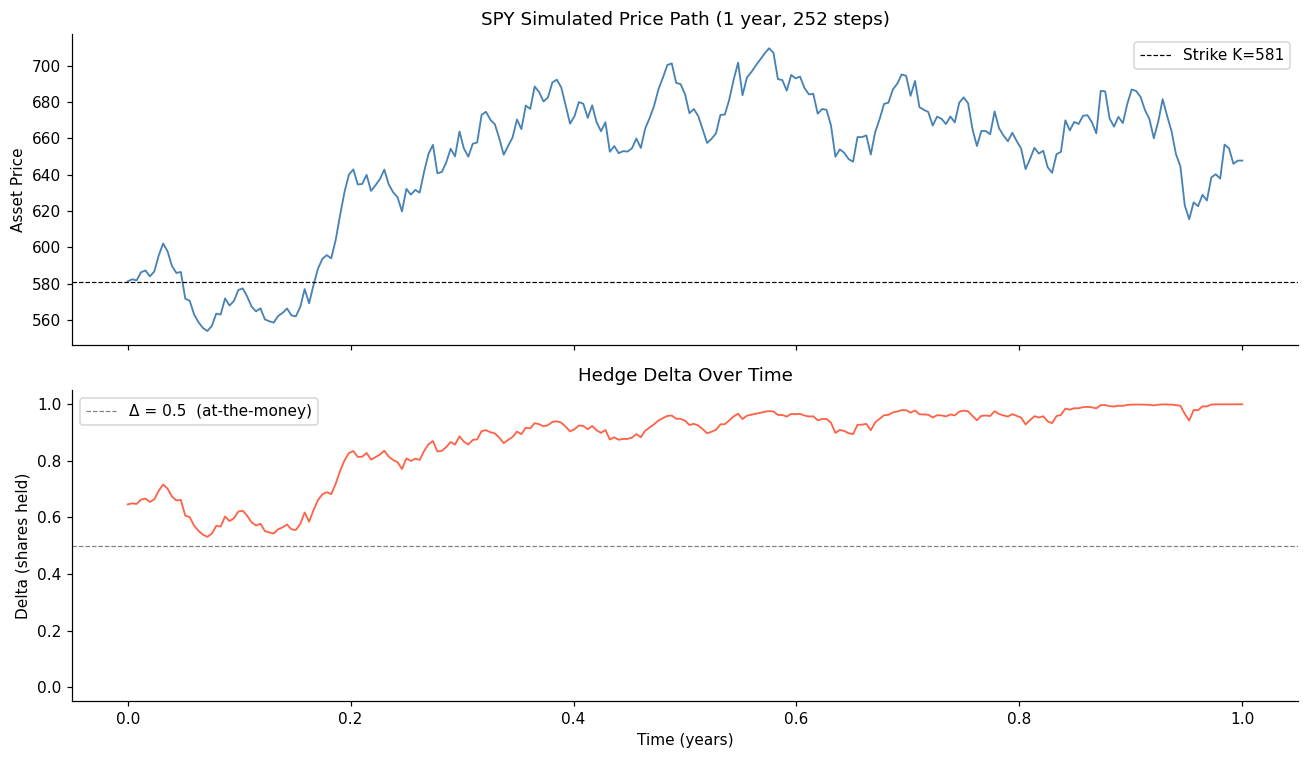

In [8]:
# Visualise a Single Hedged Path
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# Asset price path
axes[0].plot(times, S_path, color="steelblue", linewidth=1.2)
axes[0].axhline(K, color="black", linestyle="--", linewidth=0.8, label=f"Strike K={K:.0f}")
axes[0].set_title(f"{ticker} Simulated Price Path (1 year, 252 steps)")
axes[0].set_ylabel("Asset Price")
axes[0].legend()

# Delta through time
axes[1].plot(times, deltas, color="tomato", linewidth=1.2)
axes[1].axhline(0.5, color="black", linestyle="--", linewidth=0.8, alpha=0.5,
                label="Δ = 0.5  (at-the-money)")
axes[1].set_title("Hedge Delta Over Time")
axes[1].set_xlabel("Time (years)")
axes[1].set_ylabel("Delta (shares held)")
axes[1].set_ylim(-0.05, 1.05)
axes[1].legend()

plt.tight_layout()
plt.show()

Weekly   (52 steps)             mean=+0.1099  std=4.6095
Daily   (252 steps)             mean=+0.0104  std=2.0639
Twice daily (504)               mean=+0.0064  std=1.4697


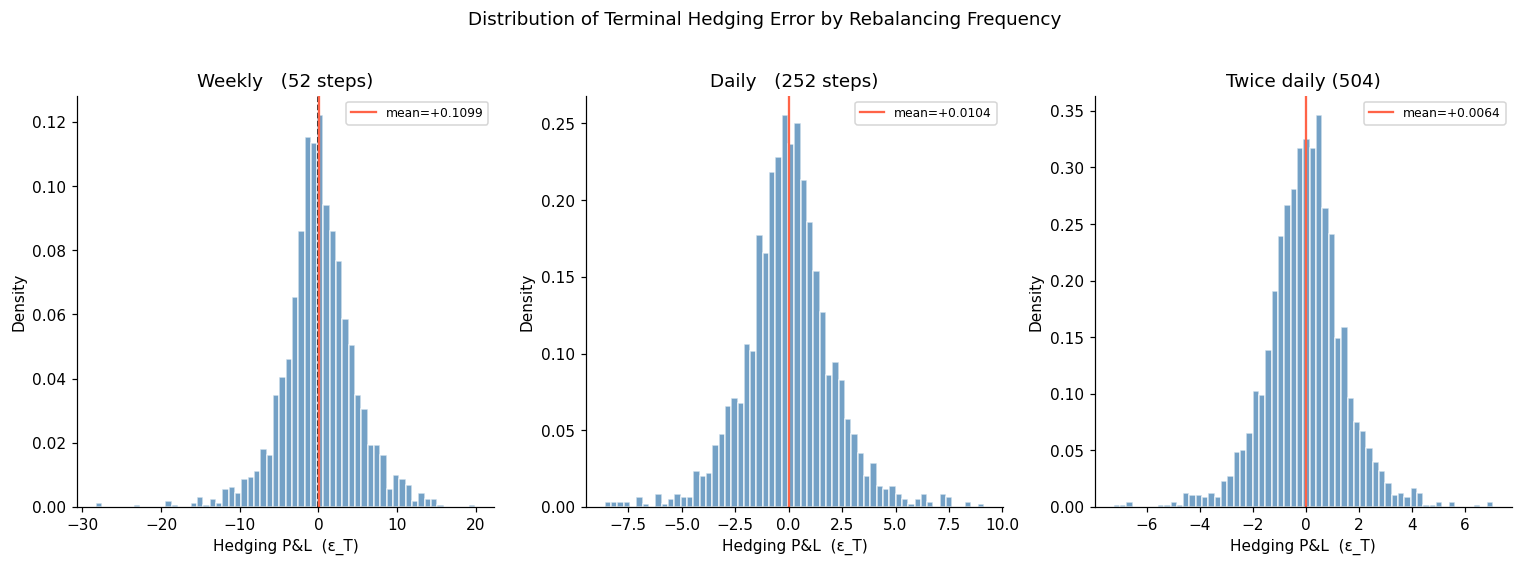

In [9]:
# Hedging Error vs Rebalancing Frequency
N_PATHS     = 2_000
rebal_freqs = {
    "Weekly   (52 steps)" : 52,
    "Daily   (252 steps)" : 252,
    "Twice daily (504)"   : 504,
}

pnl_by_freq = {}

for label, n_steps in rebal_freqs.items():
    pnls = []
    for path_idx in range(N_PATHS):
        _, _, _, pnl = simulate_hedge_path(
            S0, K, T, r_f,
            sigma_true=sigma,
            sigma_hedge=sigma,
            n_steps=n_steps,
            seed=path_idx
        )
        pnls.append(pnl)
    pnl_by_freq[label] = np.array(pnls)
    print(f"{label:30s}  mean={np.mean(pnls):+.4f}  std={np.std(pnls):.4f}")

fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=False)

for ax, (label, pnls) in zip(axes, pnl_by_freq.items()):
    ax.hist(pnls, bins=60, color="steelblue", alpha=0.75, density=True, edgecolor="white")
    ax.axvline(0, color="black", linewidth=1.0, linestyle="--")
    ax.axvline(np.mean(pnls), color="tomato", linewidth=1.5,
               label=f"mean={np.mean(pnls):+.4f}")
    ax.set_title(label)
    ax.set_xlabel("Hedging P&L  (ε_T)")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

plt.suptitle("Distribution of Terminal Hedging Error by Rebalancing Frequency",
             y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

n_steps=  12  std(P&L)=9.4199
n_steps=  26  std(P&L)=6.5753
n_steps=  52  std(P&L)=4.6095
n_steps= 105  std(P&L)=3.1688
n_steps= 252  std(P&L)=2.0639
n_steps= 504  std(P&L)=1.4697
n_steps= 756  std(P&L)=1.2326


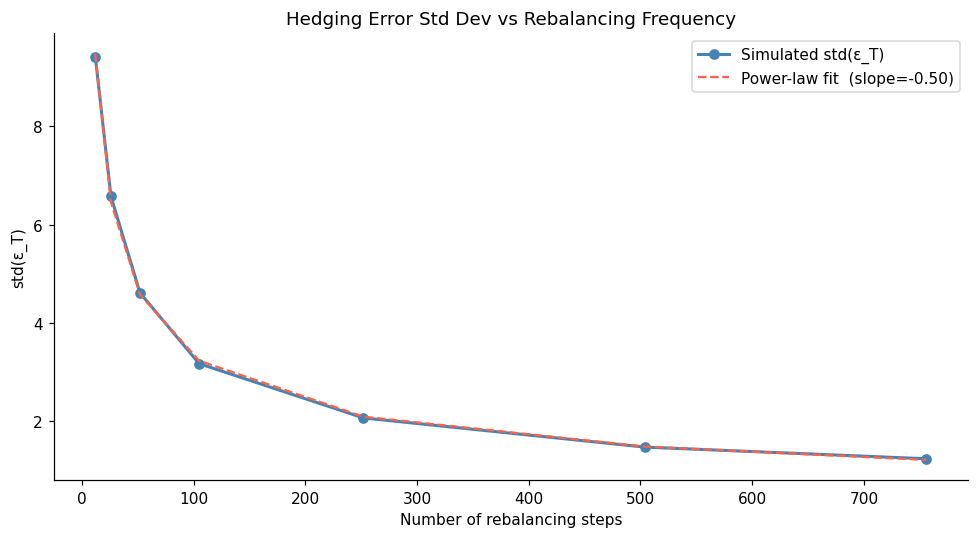


Fitted power-law exponent : -0.497
Theory predicts           : -0.500


In [10]:
# Hedging Error Std Dev vs Rebalancing Frequency
step_counts = [12, 26, 52, 105, 252, 504, 756]
labels_freq = ["Monthly", "Biweekly", "Weekly", "Twice\nWeekly",
               "Daily", "Twice\nDaily", "3x\nDaily"]
std_pnls    = []

for n_steps in step_counts:
    pnls = []
    for path_idx in range(N_PATHS):
        _, _, _, pnl = simulate_hedge_path(
            S0, K, T, r_f,
            sigma_true=sigma,
            sigma_hedge=sigma,
            n_steps=n_steps,
            seed=path_idx
        )
        pnls.append(pnl)
    std_pnls.append(np.std(pnls))
    print(f"n_steps={n_steps:4d}  std(P&L)={np.std(pnls):.4f}")

# Theoretical prediction: std of hedging error ∝ 1/sqrt(n_steps)
# Fit a scaling curve for comparison
coeffs = np.polyfit(np.log(step_counts), np.log(std_pnls), 1)
fit_std = np.exp(coeffs[1]) * np.array(step_counts)**coeffs[0]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(step_counts, std_pnls, marker="o", color="steelblue",
        linewidth=2, markersize=6, label="Simulated std(ε_T)")
ax.plot(step_counts, fit_std, color="tomato", linestyle="--",
        linewidth=1.5, label=f"Power-law fit  (slope={coeffs[0]:.2f})")
ax.set_title("Hedging Error Std Dev vs Rebalancing Frequency")
ax.set_xlabel("Number of rebalancing steps")
ax.set_ylabel("std(ε_T)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nFitted power-law exponent : {coeffs[0]:.3f}")
print(f"Theory predicts           : -0.500")

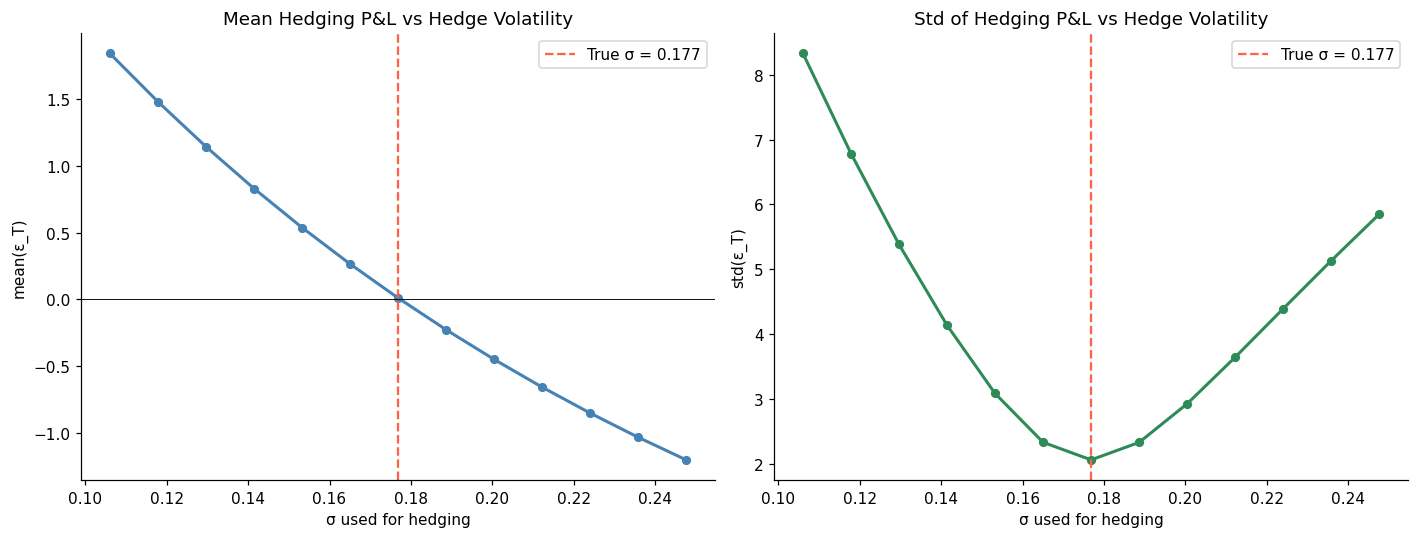

Interpretation:
  Hedging with σ > σ_true : option writer systematically over-hedges → positive mean P&L
  Hedging with σ < σ_true : option writer systematically under-hedges → negative mean P&L
  The std curve is minimised at σ_hedge = σ_true, confirming correct specification
  is optimal in terms of hedging error variance.


In [11]:
# Effect of Volatility Misspecification
# What happens when the hedger uses the wrong sigma to compute deltas?
# sigma_true is fixed; sigma_hedge is varied around it.

N_STEPS      = 252
sigma_hedges = np.linspace(sigma * 0.6, sigma * 1.4, 13)  # ±40% around true sigma
mean_pnls    = []
std_pnls_mis = []

for sigma_h in sigma_hedges:
    pnls = []
    for path_idx in range(N_PATHS):
        _, _, _, pnl = simulate_hedge_path(
            S0, K, T, r_f,
            sigma_true=sigma,
            sigma_hedge=sigma_h,
            n_steps=N_STEPS,
            seed=path_idx
        )
        pnls.append(pnl)
    mean_pnls.append(np.mean(pnls))
    std_pnls_mis.append(np.std(pnls))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Mean P&L vs misspecification
axes[0].plot(sigma_hedges, mean_pnls, marker="o", color="steelblue",
             linewidth=2, markersize=5)
axes[0].axvline(sigma, color="tomato", linestyle="--", linewidth=1.5,
                label=f"True σ = {sigma:.3f}")
axes[0].axhline(0, color="black", linewidth=0.6)
axes[0].set_title("Mean Hedging P&L vs Hedge Volatility")
axes[0].set_xlabel("σ used for hedging")
axes[0].set_ylabel("mean(ε_T)")
axes[0].legend()

# Std P&L vs misspecification
axes[1].plot(sigma_hedges, std_pnls_mis, marker="o", color="seagreen",
             linewidth=2, markersize=5)
axes[1].axvline(sigma, color="tomato", linestyle="--", linewidth=1.5,
                label=f"True σ = {sigma:.3f}")
axes[1].set_title("Std of Hedging P&L vs Hedge Volatility")
axes[1].set_xlabel("σ used for hedging")
axes[1].set_ylabel("std(ε_T)")
axes[1].legend()

plt.tight_layout()
plt.show()

print("Interpretation:")
print("  Hedging with σ > σ_true : option writer systematically over-hedges → positive mean P&L")
print("  Hedging with σ < σ_true : option writer systematically under-hedges → negative mean P&L")
print("  The std curve is minimised at σ_hedge = σ_true, confirming correct specification")
print("  is optimal in terms of hedging error variance.")

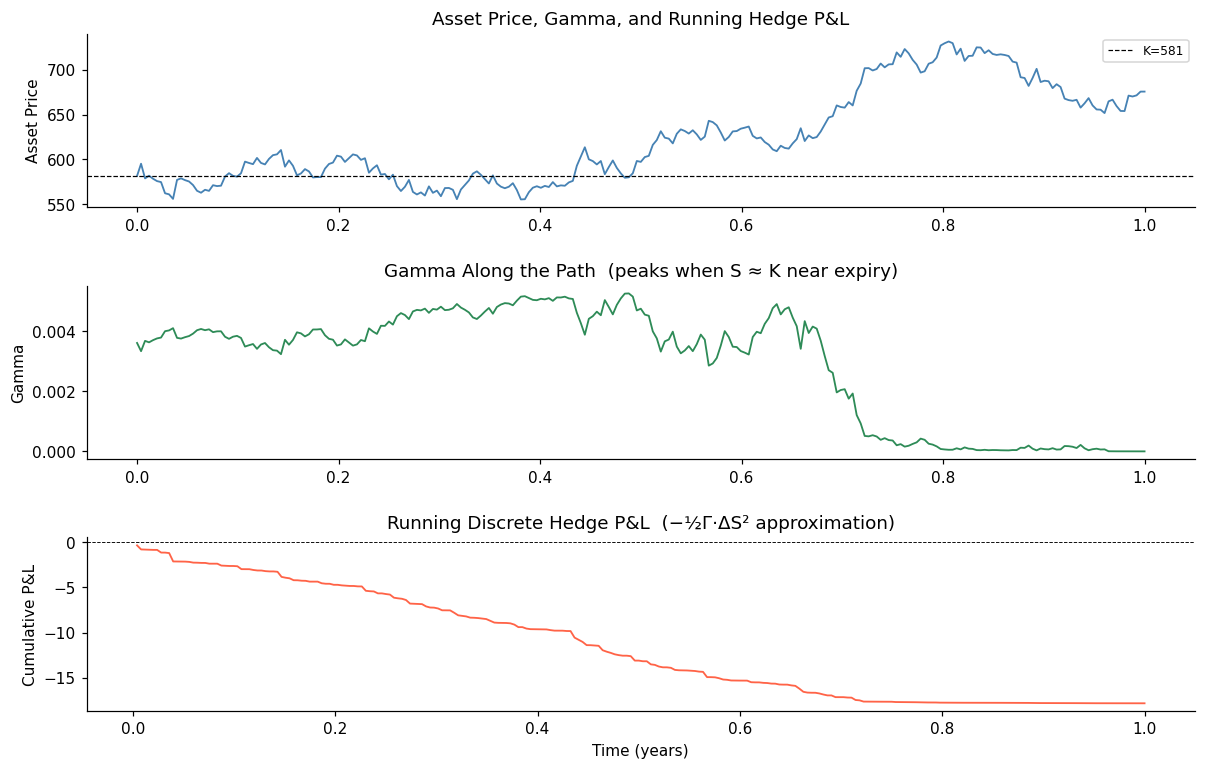

In [12]:
# Gamma Exposure and Hedging Error
# High gamma means delta is changing rapidly — discrete rebalancing
# introduces more error when gamma is large.
# We visualise gamma along a single path alongside the running P&L.

N_STEPS   = 252
times, S_path, deltas, _ = simulate_hedge_path(
    S0, K, T, r_f, sigma, sigma, n_steps=N_STEPS, seed=3
)

# Compute gamma at every point along the path
gammas = np.array([
    bs_gamma(S_path[i], K, T - times[i], r_f, sigma)
    for i in range(N_STEPS + 1)
])

# Running cumulative P&L approximation:
# at each step the hedge error increment ≈ -0.5 * gamma * (dS)^2
dS         = np.diff(S_path)
gamma_mid  = gammas[:-1]
running_pnl = np.cumsum(-0.5 * gamma_mid * dS**2)

fig = plt.figure(figsize=(13, 8))
gs  = gridspec.GridSpec(3, 1, hspace=0.45)

# Asset price
ax0 = fig.add_subplot(gs[0])
ax0.plot(times, S_path, color="steelblue", linewidth=1.2)
ax0.axhline(K, color="black", linestyle="--", linewidth=0.8, label=f"K={K:.0f}")
ax0.set_ylabel("Asset Price")
ax0.set_title("Asset Price, Gamma, and Running Hedge P&L")
ax0.legend(fontsize=8)

# Gamma
ax1 = fig.add_subplot(gs[1])
ax1.plot(times, gammas, color="seagreen", linewidth=1.2)
ax1.set_ylabel("Gamma")
ax1.set_title("Gamma Along the Path  (peaks when S ≈ K near expiry)")

# Running P&L
ax2 = fig.add_subplot(gs[2])
ax2.plot(times[1:], running_pnl, color="tomato", linewidth=1.2)
ax2.axhline(0, color="black", linewidth=0.6, linestyle="--")
ax2.set_ylabel("Cumulative P&L")
ax2.set_xlabel("Time (years)")
ax2.set_title("Running Discrete Hedge P&L  (−½Γ·ΔS² approximation)")

plt.show()

In [14]:
# Summary Dashboard
# Collect key statistics across all experiments into one summary table

summary_rows = []

# Rebalancing frequency results
for label, n_steps in rebal_freqs.items():
    pnls = pnl_by_freq[label]
    summary_rows.append({
        "Experiment"       : f"Rebal freq — {label.strip()}",
        "n_steps"          : n_steps,
        "σ_hedge / σ_true" : 1.0,
        "mean(ε_T)"        : np.mean(pnls),
        "std(ε_T)"         : np.std(pnls),
        "5th pct"          : np.percentile(pnls, 5),
        "95th pct"         : np.percentile(pnls, 95),
    })

# Misspecification results at ±20% and ±40%
for frac, label in [(0.80, "σ_hedge = 0.80·σ"), (0.90, "σ_hedge = 0.90·σ"),
                    (1.00, "σ_hedge = 1.00·σ  (correct)"),
                    (1.10, "σ_hedge = 1.10·σ"), (1.20, "σ_hedge = 1.20·σ")]:
    pnls = []
    for path_idx in range(N_PATHS):
        _, _, _, pnl = simulate_hedge_path(
            S0, K, T, r_f,
            sigma_true=sigma,
            sigma_hedge=sigma * frac,
            n_steps=252,
            seed=path_idx
        )
        pnls.append(pnl)
    summary_rows.append({
        "Experiment"       : f"Misspec — {label}",
        "n_steps"          : 252,
        "σ_hedge / σ_true" : frac,
        "mean(ε_T)"        : np.mean(pnls),
        "std(ε_T)"         : np.std(pnls),
        "5th pct"          : np.percentile(pnls, 5),
        "95th pct"         : np.percentile(pnls, 95),
    })

summary_df = pd.DataFrame(summary_rows).round(4)

print("=" * 105)
print("  Delta Hedging Summary")
print("=" * 105)
print(summary_df.to_string(index=False))
print("=" * 105)

  Delta Hedging Summary
                           Experiment  n_steps  σ_hedge / σ_true  mean(ε_T)  std(ε_T)  5th pct  95th pct
     Rebal freq — Weekly   (52 steps)       52               1.0     0.1099    4.6095  -7.2165    7.6124
     Rebal freq — Daily   (252 steps)      252               1.0     0.0104    2.0639  -3.2460    3.2853
       Rebal freq — Twice daily (504)      504               1.0     0.0064    1.4697  -2.3025    2.3415
           Misspec — σ_hedge = 0.80·σ      252               0.8     0.8306    4.1381  -6.6779    6.2216
           Misspec — σ_hedge = 0.90·σ      252               0.9     0.3994    2.6632  -4.4529    3.7898
Misspec — σ_hedge = 1.00·σ  (correct)      252               1.0     0.0104    2.0639  -3.2460    3.2853
           Misspec — σ_hedge = 1.10·σ      252               1.1    -0.3409    2.6056  -3.7976    4.4600
           Misspec — σ_hedge = 1.20·σ      252               1.2    -0.6583    3.6457  -5.6803    5.9570


## Summary and Conclusions

### What We Found

| Question | Finding |
|---|---|
| Does discrete hedging work? | Yes — mean P&L is near zero; errors arise from randomness, not bias |
| How does frequency affect error? | std(ε_T) decays as roughly $n^{-0.5}$ — halving error requires 4× the rebalancing |
| What does misspecification do? | Hedging with wrong σ introduces a systematic mean bias in P&L |
| Where does hedging error come from? | High-gamma regions near the strike, especially close to expiry |

### Limitations of the GBM Hedging Framework

The analysis in this notebook assumes:
- **Continuous, liquid markets** — in practice, bid-ask spreads make frequent
  rebalancing costly
- **Constant volatility** — as shown in Notebook 02, real volatility is
  time-varying; a stochastic volatility model would produce larger and more
  realistic hedging errors
- **No jumps** — large discontinuous price moves (e.g. earnings announcements)
  cannot be hedged by delta alone

### Natural Extensions

These limitations point directly to the future extensions listed in the project README:

- **Heston model** — stochastic volatility would widen the P&L distribution
  significantly compared to constant-σ GBM
- **Transaction costs** — adding a cost per share traded would create an
  optimal rebalancing frequency that trades off hedging error against cost
- **Jump-diffusion** — Merton's model adds Poisson jumps and produces
  irreducible hedging error even under continuous rebalancing